# Analysis: GPU NR Revert vs Original GPU & CPU — Branch Length Estimation

**Revert dataset:** `2026_03_16_bl_estimation_gpu_NR_revert` — GPU OpenACC with NR revert (DNA: GTR only, AA: LG only)  
**Baseline dataset:** `2026_03_16_bl_estimation` — GPU OpenACC + CPU (VANILA, OMP_10, OMP_48)  
**Dataset:** 100 taxa, 1M sites, 10 different trees, 10 runs each  
**Comparison:** Optimization time, wall-clock time, numerical accuracy (log-likelihood)

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

revert_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation_gpu_NR_revert"
original_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation"
save_dir = os.getcwd()

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Parse all log files

In [2]:
initial_ll_pattern = re.compile(r"Initial log-likelihood:\s+([-0-9.]+)")
optimal_ll_pattern = re.compile(r"Optimal log-likelihood:\s+([-0-9.]+)")
params_opt_pattern = re.compile(r"Parameters optimization took (\d+) rounds? \(([0-9.]+) sec\)")
wallclock_pattern = re.compile(r"Total wall-clock time used:\s+([0-9.]+)\s+sec")
best_score_pattern = re.compile(r"BEST SCORE FOUND\s*:\s*([-0-9.]+)")

def parse_log(filepath):
    """Parse a single IQ-TREE log file."""
    result = {}
    try:
        with open(filepath, 'r') as f:
            text = f.read()
    except:
        return None
    
    m = initial_ll_pattern.search(text)
    if m: result['initial_ll'] = float(m.group(1))
    
    m = optimal_ll_pattern.search(text)
    if m: result['optimal_ll'] = float(m.group(1))
    
    m = params_opt_pattern.search(text)
    if m:
        result['opt_rounds'] = int(m.group(1))
        result['opt_time'] = float(m.group(2))
    
    m = wallclock_pattern.search(text)
    if m: result['wallclock'] = float(m.group(1))
    
    m = best_score_pattern.search(text)
    if m: result['best_score'] = float(m.group(1))
    
    return result if result else None

def parse_all_logs(results_path, source_label):
    """Parse all IQ-TREE log files from a results directory."""
    rows = []
    
    for data_type in ['AA', 'DNA']:
        data_dir = os.path.join(results_path, data_type)
        if not os.path.exists(data_dir): continue
        
        for tree_type in ['rooted', 'unrooted']:
            tree_type_dir = os.path.join(data_dir, tree_type)
            if not os.path.exists(tree_type_dir): continue
            
            for model in sorted(os.listdir(tree_type_dir)):
                model_dir = os.path.join(tree_type_dir, model)
                if not os.path.isdir(model_dir): continue
                
                for tree_dir_name in sorted(os.listdir(model_dir)):
                    tree_dir = os.path.join(model_dir, tree_dir_name)
                    if not os.path.isdir(tree_dir): continue
                    
                    tree_num = tree_dir_name.replace('tree_', '')
                    
                    for f in sorted(os.listdir(tree_dir)):
                        if not f.endswith('.log'): continue
                        
                        # Determine backend
                        if 'GPU_NR' in f and 'OPENACC' in f:
                            backend = 'GPU_NR_REVERT'
                        elif 'OPENACC' in f:
                            backend = 'OPENACC'
                        elif 'VANILA' in f:
                            backend = 'VANILA'
                        elif 'OMP_48' in f:
                            backend = 'OMP_48'
                        elif 'OMP_10' in f:
                            backend = 'OMP_10'
                        else:
                            backend = 'UNKNOWN'
                        
                        # Extract run number
                        run_match = re.search(r'run(\d+)_tree', f.split('iqtree3')[-1] if 'iqtree3' in f else f)
                        if not run_match:
                            run_match = re.search(r'run(\d+)_tree', f)
                        run_num = int(run_match.group(1)) if run_match else 0
                        
                        parsed = parse_log(os.path.join(tree_dir, f))
                        if parsed:
                            parsed.update({
                                'data_type': data_type,
                                'tree_type': tree_type,
                                'model': model,
                                'tree': int(tree_num),
                                'run': run_num,
                                'backend': backend,
                                'source': source_label,
                            })
                            rows.append(parsed)
    
    return pd.DataFrame(rows)

df_revert = parse_all_logs(revert_path, 'revert')
df_original = parse_all_logs(original_path, 'original')

df = pd.concat([df_revert, df_original], ignore_index=True)
print(f"Revert rows: {len(df_revert)}, Original rows: {len(df_original)}, Total: {len(df)}")
print(f"\nBackend counts:")
print(df.groupby(['source', 'backend', 'data_type', 'model']).size().to_string())

Revert rows: 200, Original rows: 6400, Total: 6600

Backend counts:
source    backend        data_type  model  
original  OMP_10         AA         JTT        200
                                    LG         200
                                    Poisson    200
                                    WAG        200
                         DNA        GTR        200
                                    HKY        200
                                    JC         200
                                    K2P        200
          OMP_48         AA         JTT        200
                                    LG         200
                                    Poisson    200
                                    WAG        200
                         DNA        GTR        200
                                    HKY        200
                                    JC         200
                                    K2P        200
          OPENACC        AA         JTT        200
                     

In [3]:
df.head(10)

,initial_ll,optimal_ll,opt_rounds,opt_time,wallclock,best_score,data_type,tree_type,model,tree,run,backend,source
0,-88901525.36,-8.890142e+07,1.0,15.621,18.647,-8.890142e+07,AA,unrooted,LG,1,10,GPU_NR_REVERT,revert
1,-88901525.36,-8.890142e+07,1.0,15.579,18.498,-8.890142e+07,AA,unrooted,LG,1,1,GPU_NR_REVERT,revert
2,-88901525.36,-8.890142e+07,1.0,15.591,18.468,-8.890142e+07,AA,unrooted,LG,1,2,GPU_NR_REVERT,revert
3,-88901525.36,-8.890142e+07,1.0,15.555,18.499,-8.890142e+07,AA,unrooted,LG,1,3,GPU_NR_REVERT,revert
4,-88901525.36,-8.890142e+07,1.0,15.553,18.447,-8.890142e+07,AA,unrooted,LG,1,4,GPU_NR_REVERT,revert
5,-88901525.36,-8.890142e+07,1.0,15.572,18.442,-8.890142e+07,AA,unrooted,LG,1,5,GPU_NR_REVERT,revert
6,-88901525.36,-8.890142e+07,1.0,15.534,18.382,-8.890142e+07,AA,unrooted,LG,1,6,GPU_NR_REVERT,revert
7,-88901525.36,-8.890142e+07,1.0,15.538,18.356,-8.890142e+07,AA,unrooted,LG,1,7,GPU_NR_REVERT,revert
8,-88901525.36,-8.890142e+07,1.0,15.596,18.504,-8.890142e+07,AA,unrooted,LG,1,8,GPU_NR_REVERT,revert
9,-88901525.36,-8.890142e+07,1.0,15.612,18.512,-8.890142e+07,AA,unrooted,LG,1,9,GPU_NR_REVERT,revert


# 2. Filter to comparable subsets (GTR for DNA, LG for AA — unrooted only)

The revert dataset only has GTR (DNA) and LG (AA), so we filter the original dataset to match.

In [4]:
# Filter to matching models and unrooted only (revert only has unrooted)
dna_mask = (df['data_type'] == 'DNA') & (df['model'] == 'GTR') & (df['tree_type'] == 'unrooted')
aa_mask = (df['data_type'] == 'AA') & (df['model'] == 'LG') & (df['tree_type'] == 'unrooted')
df_cmp = df[dna_mask | aa_mask].copy()

print(f"Comparable subset: {len(df_cmp)} rows")
print(df_cmp.groupby(['data_type', 'model', 'backend']).size().unstack(fill_value=0))

Comparable subset: 1000 rows
backend          GPU_NR_REVERT  OMP_10  OMP_48  OPENACC  VANILA
data_type model                                                
AA        LG               100     100     100      100     100
DNA       GTR              100     100     100      100     100


# 3. Summary Statistics: Optimization Time

In [5]:
# Compute summary stats per backend
for dt in ['DNA', 'AA']:
    model = 'GTR' if dt == 'DNA' else 'LG'
    subset = df_cmp[df_cmp['data_type'] == dt]
    print(f"\n{'='*70}")
    print(f"{dt} — {model} (unrooted)")
    print(f"{'='*70}")
    
    summary = subset.groupby('backend').agg(
        opt_time_mean=('opt_time', 'mean'),
        opt_time_std=('opt_time', 'std'),
        opt_time_median=('opt_time', 'median'),
        wallclock_mean=('wallclock', 'mean'),
        wallclock_std=('wallclock', 'std'),
        wallclock_median=('wallclock', 'median'),
        opt_rounds_mean=('opt_rounds', 'mean'),
        optimal_ll_mean=('optimal_ll', 'mean'),
        count=('wallclock', 'count'),
    ).round(3)
    
    print(summary.to_string())
    
    # Speedup vs VANILA
    if 'VANILA' in summary.index:
        vanila_opt = summary.loc['VANILA', 'opt_time_mean']
        vanila_wc = summary.loc['VANILA', 'wallclock_mean']
        print(f"\nSpeedup vs VANILA (CPU 1-core):")
        for backend in summary.index:
            opt_speedup = vanila_opt / summary.loc[backend, 'opt_time_mean']
            wc_speedup = vanila_wc / summary.loc[backend, 'wallclock_mean']
            print(f"  {backend:20s}: opt_time {opt_speedup:.2f}x, wallclock {wc_speedup:.2f}x")


DNA — GTR (unrooted)
               opt_time_mean  opt_time_std  opt_time_median  wallclock_mean  wallclock_std  wallclock_median  opt_rounds_mean  optimal_ll_mean  count
backend                                                                                                                                              
GPU_NR_REVERT         15.781         2.801           14.482          18.543          2.800            17.240             5.20    -6.743701e+07    100
OMP_10                35.668        17.167           32.934          36.821         17.175            34.085             5.20    -6.743701e+07    100
OMP_48                14.337         3.678           12.892          15.433          3.684            13.972             5.20    -6.743701e+07    100
OPENACC               16.287         2.980           14.806          19.057          2.978            17.581             5.25    -6.737304e+07     96
VANILA               142.413        36.725          117.590         144.966   

# 4. Numerical Accuracy: Log-Likelihood Comparison

In [6]:
# Compare log-likelihoods across backends for each (data_type, tree) pair
for dt in ['DNA', 'AA']:
    model = 'GTR' if dt == 'DNA' else 'LG'
    subset = df_cmp[df_cmp['data_type'] == dt]
    
    print(f"\n{'='*70}")
    print(f"{dt} — {model}: Log-Likelihood per tree (mean over 10 runs)")
    print(f"{'='*70}")
    
    pivot = subset.groupby(['tree', 'backend'])['optimal_ll'].mean().unstack()
    print(pivot.round(4).to_string())
    
    # Compute absolute differences
    print(f"\nAbsolute difference from VANILA (CPU 1-core):")
    if 'VANILA' in pivot.columns:
        for backend in pivot.columns:
            if backend == 'VANILA': continue
            diff = (pivot[backend] - pivot['VANILA']).abs()
            print(f"  {backend:20s}: max={diff.max():.6f}, mean={diff.mean():.6f}")
    
    # Also compare GPU_NR_REVERT vs OPENACC directly
    if 'GPU_NR_REVERT' in pivot.columns and 'OPENACC' in pivot.columns:
        diff_gpu = (pivot['GPU_NR_REVERT'] - pivot['OPENACC']).abs()
        print(f"\n  GPU_NR_REVERT vs OPENACC: max={diff_gpu.max():.6f}, mean={diff_gpu.mean():.6f}")


DNA — GTR: Log-Likelihood per tree (mean over 10 runs)
backend  GPU_NR_REVERT        OMP_10        OMP_48       OPENACC        VANILA
tree                                                                          
1        -6.434341e+07 -6.434341e+07 -6.434341e+07 -6.434341e+07 -6.434341e+07
2        -6.621779e+07 -6.621779e+07 -6.621779e+07 -6.621779e+07 -6.621779e+07
3        -6.677554e+07 -6.677554e+07 -6.677554e+07 -6.677554e+07 -6.677554e+07
4        -6.879684e+07 -6.879684e+07 -6.879684e+07 -6.879684e+07 -6.879684e+07
5        -6.805488e+07 -6.805488e+07 -6.805488e+07 -6.805488e+07 -6.805488e+07
6        -6.274397e+07 -6.274397e+07 -6.274397e+07 -6.274397e+07 -6.274397e+07
7        -6.799436e+07 -6.799436e+07 -6.799436e+07 -6.799436e+07 -6.799436e+07
8        -6.753344e+07 -6.753344e+07 -6.753344e+07 -6.753344e+07 -6.753344e+07
9        -7.293749e+07 -7.293749e+07 -7.293749e+07 -7.293749e+07 -7.293749e+07
10       -6.897240e+07 -6.897240e+07 -6.897240e+07 -6.897240e+07 -6.897240e

# 5. Optimization Time Box Plots

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_5074/988428528.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_opt, labels=present_backends, patch_artist=True)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_5074/988428528.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_wc, labels=present_backends, patch_artist=True)


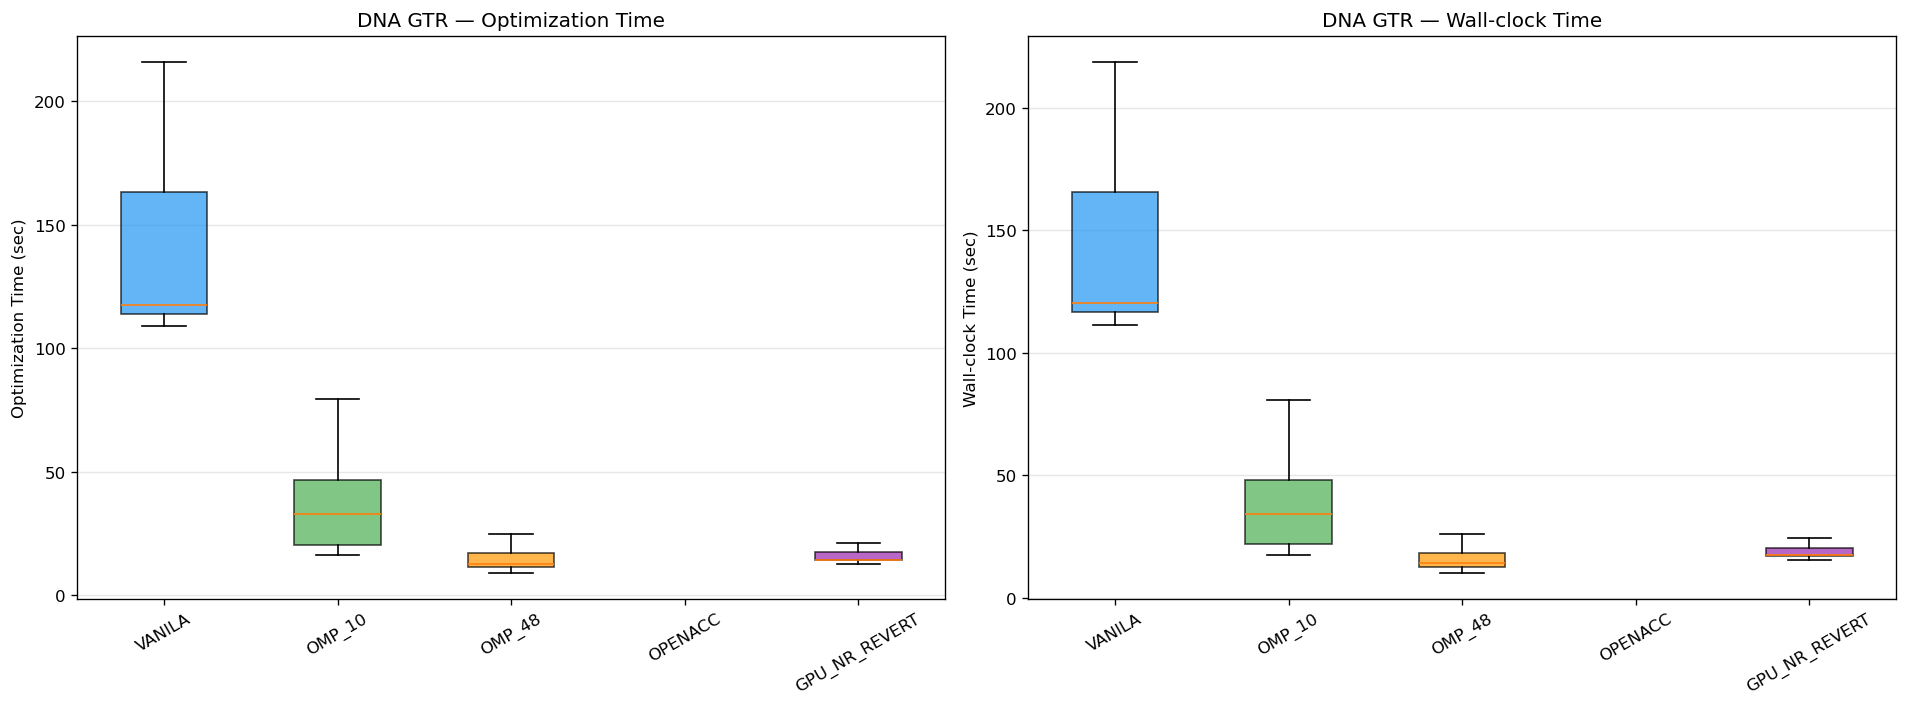

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_5074/988428528.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_opt, labels=present_backends, patch_artist=True)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_5074/988428528.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_wc, labels=present_backends, patch_artist=True)


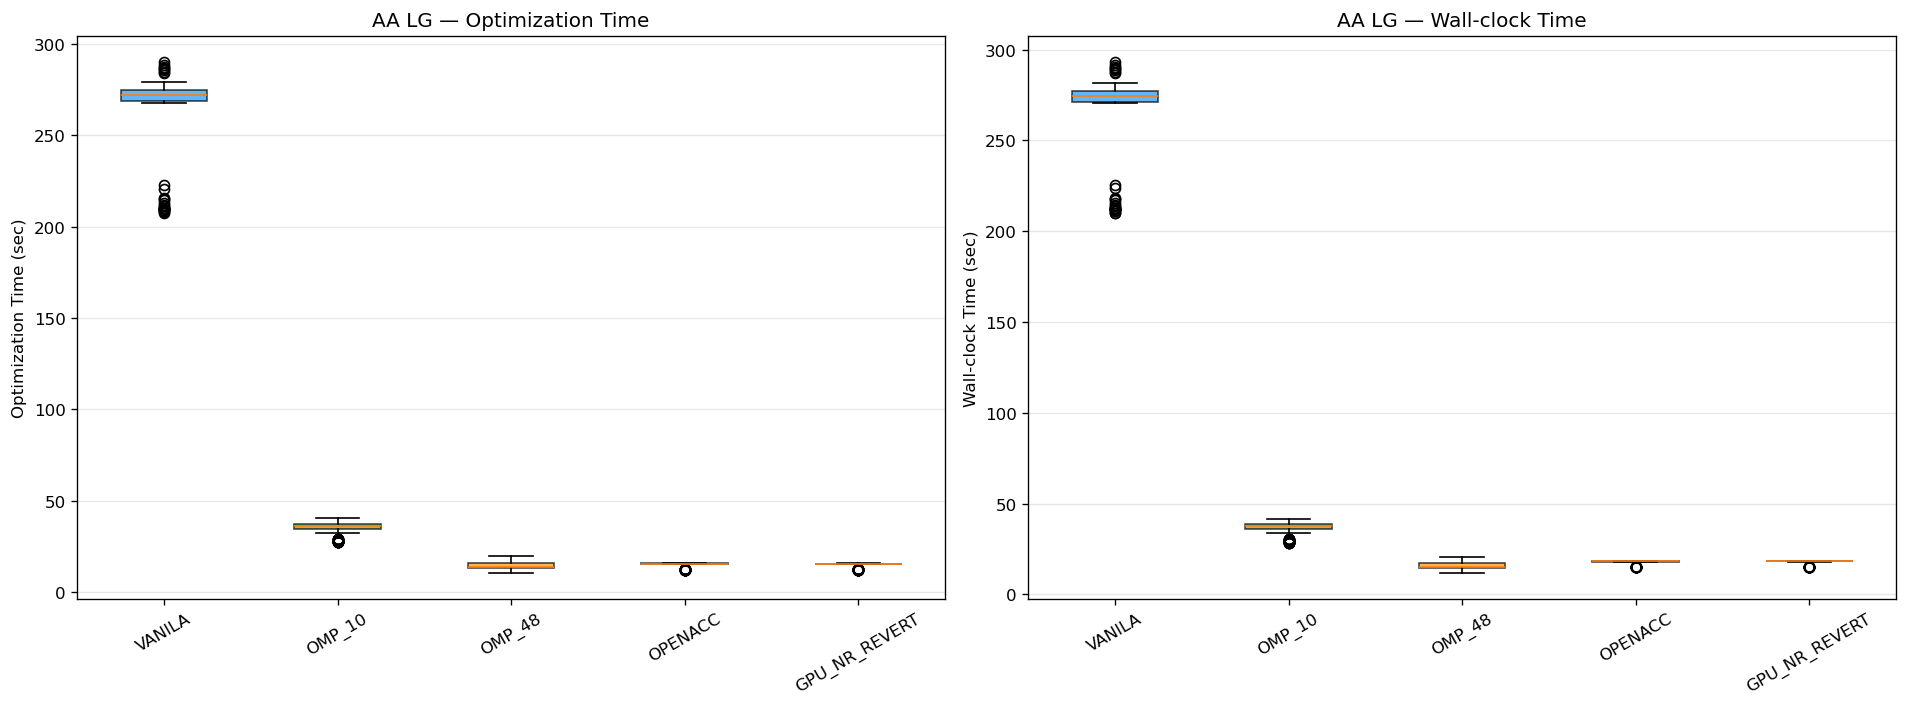

In [7]:
backend_order = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC', 'GPU_NR_REVERT']
backend_colors = {
    'VANILA': '#2196F3',
    'OMP_10': '#4CAF50',
    'OMP_48': '#FF9800',
    'OPENACC': '#E91E63',
    'GPU_NR_REVERT': '#9C27B0',
}

for dt in ['DNA', 'AA']:
    model = 'GTR' if dt == 'DNA' else 'LG'
    subset = df_cmp[df_cmp['data_type'] == dt].copy()
    present_backends = [b for b in backend_order if b in subset['backend'].unique()]
    colors = [backend_colors[b] for b in present_backends]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Optimization time
    ax = axes[0]
    data_opt = [subset[subset['backend'] == b]['opt_time'].values for b in present_backends]
    bp = ax.boxplot(data_opt, labels=present_backends, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel('Optimization Time (sec)')
    ax.set_title(f'{dt} {model} — Optimization Time')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    
    # Wall-clock time
    ax = axes[1]
    data_wc = [subset[subset['backend'] == b]['wallclock'].values for b in present_backends]
    bp = ax.boxplot(data_wc, labels=present_backends, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel('Wall-clock Time (sec)')
    ax.set_title(f'{dt} {model} — Wall-clock Time')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'timing_boxplot_{dt}.png'), bbox_inches='tight')
    plt.show()

# 6. Per-Tree Timing Comparison

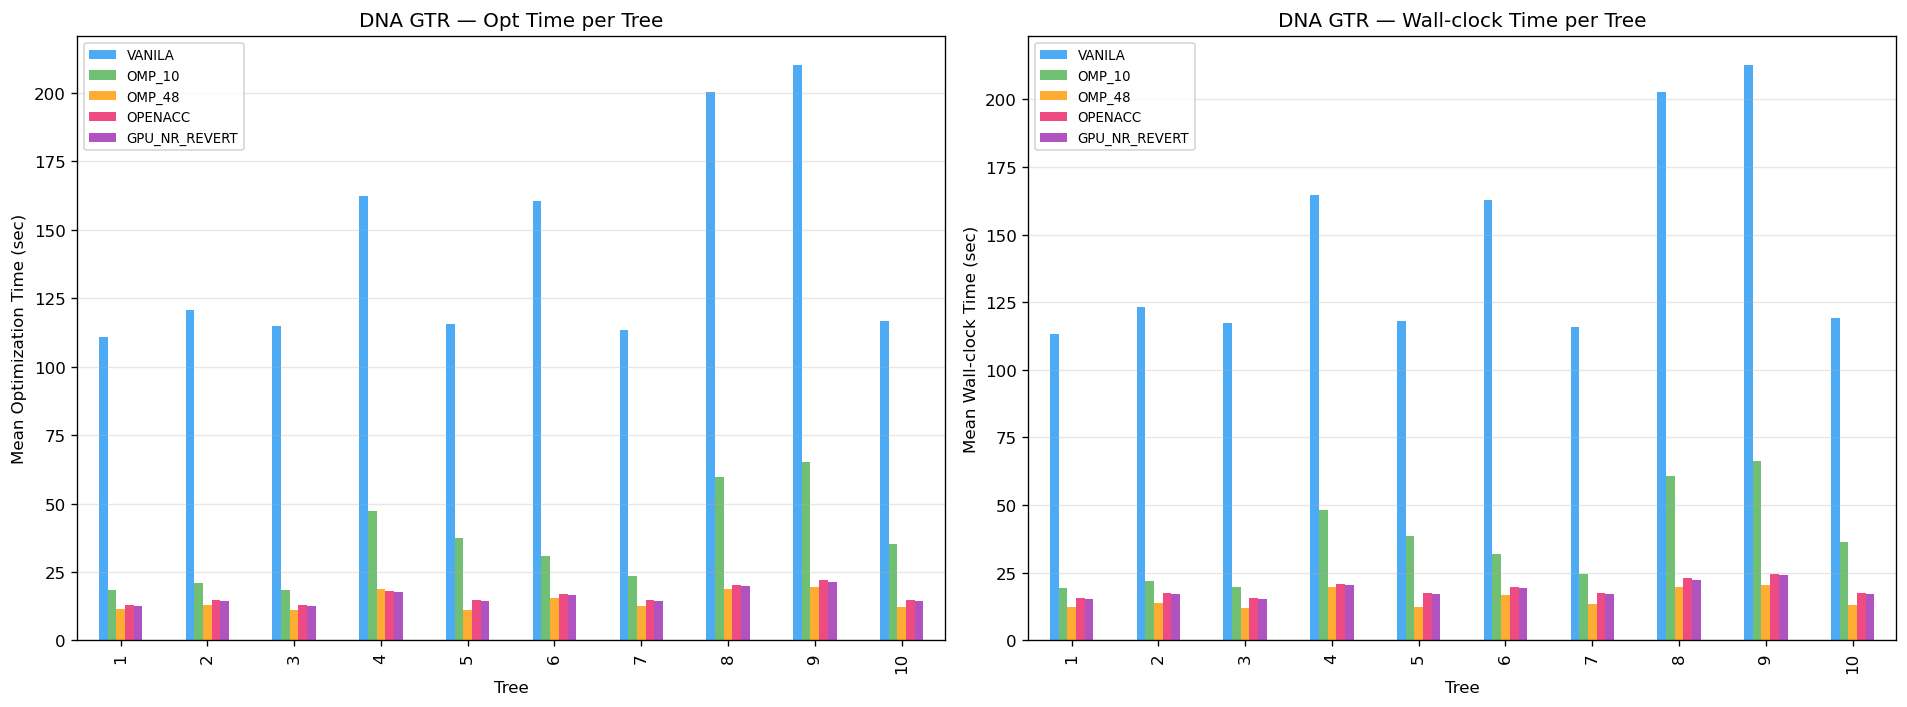

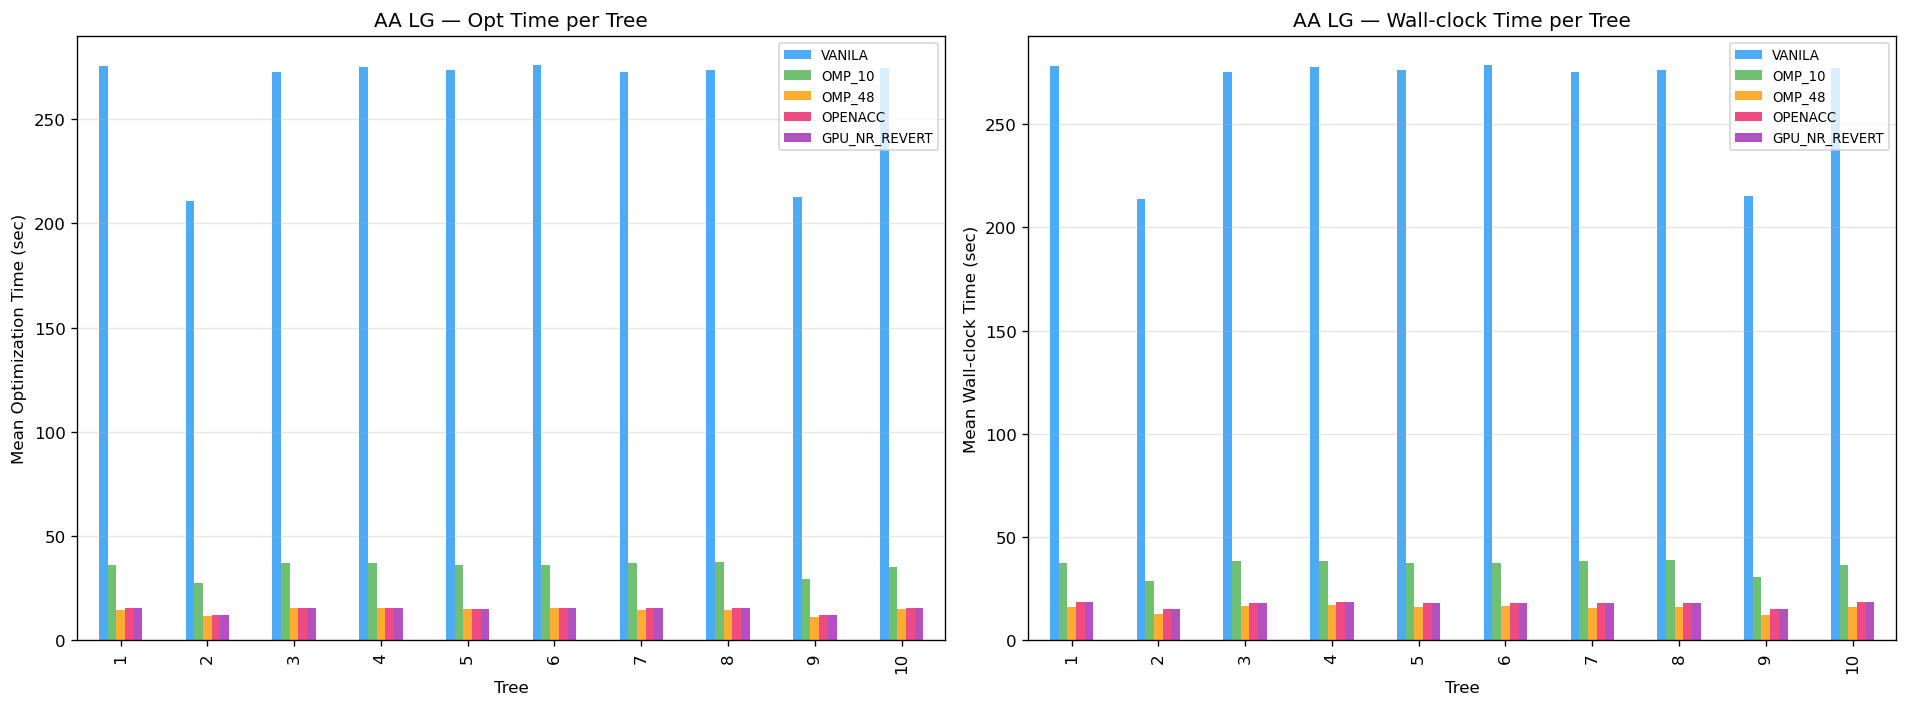

In [8]:
for dt in ['DNA', 'AA']:
    model = 'GTR' if dt == 'DNA' else 'LG'
    subset = df_cmp[df_cmp['data_type'] == dt]
    present_backends = [b for b in backend_order if b in subset['backend'].unique()]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Per-tree opt time
    pivot_opt = subset.groupby(['tree', 'backend'])['opt_time'].mean().unstack()
    pivot_opt = pivot_opt[[b for b in present_backends if b in pivot_opt.columns]]
    pivot_opt.plot(kind='bar', ax=axes[0], color=[backend_colors[b] for b in pivot_opt.columns], alpha=0.8)
    axes[0].set_ylabel('Mean Optimization Time (sec)')
    axes[0].set_title(f'{dt} {model} — Opt Time per Tree')
    axes[0].set_xlabel('Tree')
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Per-tree wallclock
    pivot_wc = subset.groupby(['tree', 'backend'])['wallclock'].mean().unstack()
    pivot_wc = pivot_wc[[b for b in present_backends if b in pivot_wc.columns]]
    pivot_wc.plot(kind='bar', ax=axes[1], color=[backend_colors[b] for b in pivot_wc.columns], alpha=0.8)
    axes[1].set_ylabel('Mean Wall-clock Time (sec)')
    axes[1].set_title(f'{dt} {model} — Wall-clock Time per Tree')
    axes[1].set_xlabel('Tree')
    axes[1].legend(fontsize=8)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'per_tree_timing_{dt}.png'), bbox_inches='tight')
    plt.show()

# 7. Speedup Analysis

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_5074/1314185529.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_opt, labels=present_backends, patch_artist=True)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_5074/1314185529.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_wc, labels=present_backends, patch_artist=True)


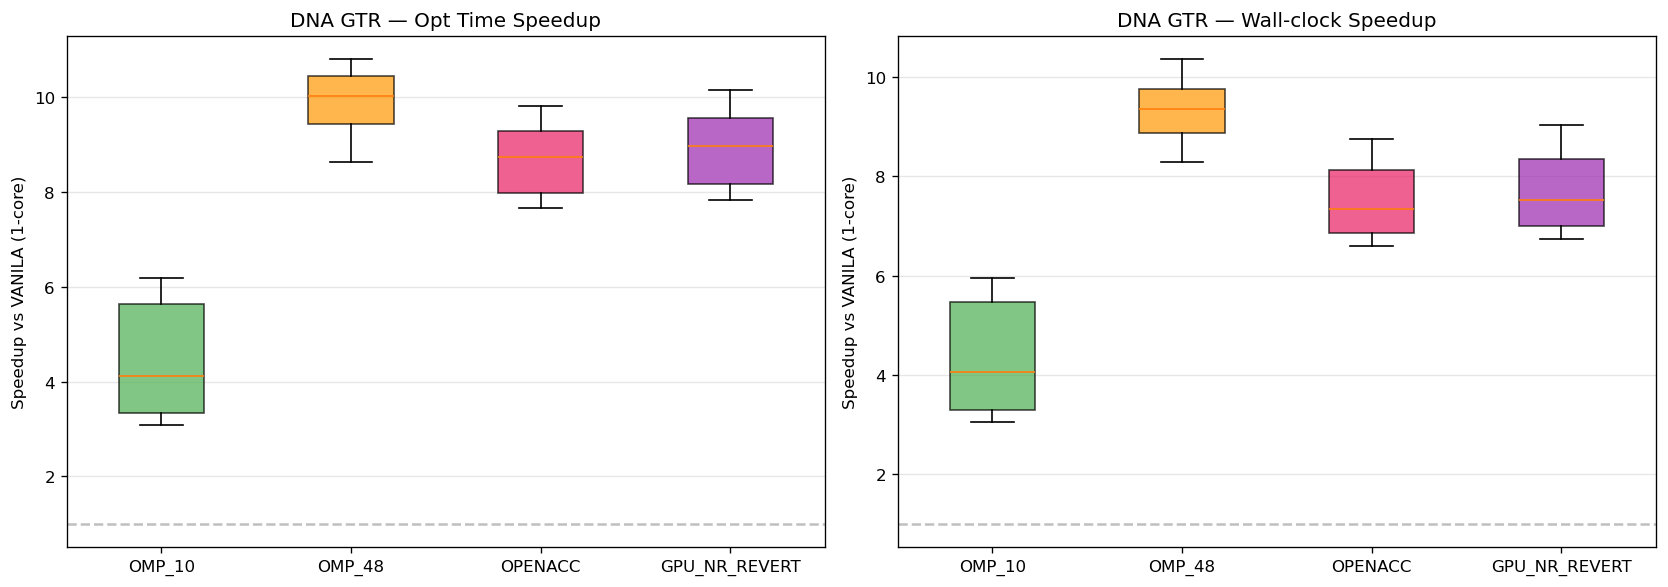

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_5074/1314185529.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_opt, labels=present_backends, patch_artist=True)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_5074/1314185529.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_wc, labels=present_backends, patch_artist=True)


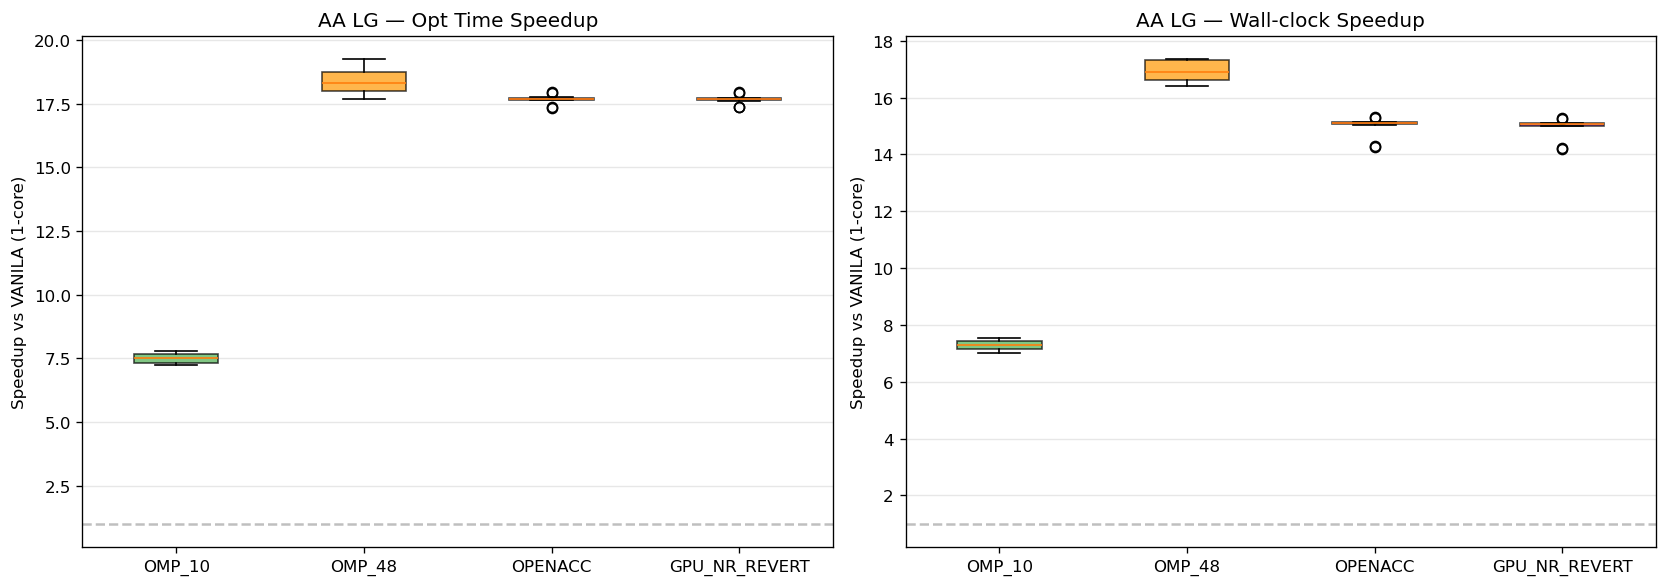

In [9]:
# Compute per-tree speedup relative to VANILA
speedup_rows = []
for dt in ['DNA', 'AA']:
    subset = df_cmp[df_cmp['data_type'] == dt]
    vanila = subset[subset['backend'] == 'VANILA'].groupby('tree')[['opt_time', 'wallclock']].mean()
    
    for backend in ['OMP_10', 'OMP_48', 'OPENACC', 'GPU_NR_REVERT']:
        bk = subset[subset['backend'] == backend].groupby('tree')[['opt_time', 'wallclock']].mean()
        common_trees = vanila.index.intersection(bk.index)
        if len(common_trees) == 0: continue
        for t in common_trees:
            speedup_rows.append({
                'data_type': dt,
                'tree': t,
                'backend': backend,
                'opt_speedup': vanila.loc[t, 'opt_time'] / bk.loc[t, 'opt_time'],
                'wc_speedup': vanila.loc[t, 'wallclock'] / bk.loc[t, 'wallclock'],
            })

df_speedup = pd.DataFrame(speedup_rows)

for dt in ['DNA', 'AA']:
    model = 'GTR' if dt == 'DNA' else 'LG'
    sub = df_speedup[df_speedup['data_type'] == dt]
    if len(sub) == 0: continue
    
    present_backends = [b for b in ['OMP_10', 'OMP_48', 'OPENACC', 'GPU_NR_REVERT'] if b in sub['backend'].unique()]
    colors = [backend_colors[b] for b in present_backends]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Opt time speedup
    data_opt = [sub[sub['backend'] == b]['opt_speedup'].values for b in present_backends]
    bp = axes[0].boxplot(data_opt, labels=present_backends, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_ylabel('Speedup vs VANILA (1-core)')
    axes[0].set_title(f'{dt} {model} — Opt Time Speedup')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Wallclock speedup
    data_wc = [sub[sub['backend'] == b]['wc_speedup'].values for b in present_backends]
    bp = axes[1].boxplot(data_wc, labels=present_backends, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    axes[1].set_ylabel('Speedup vs VANILA (1-core)')
    axes[1].set_title(f'{dt} {model} — Wall-clock Speedup')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'speedup_boxplot_{dt}.png'), bbox_inches='tight')
    plt.show()

# 8. GPU_NR_REVERT vs OPENACC Direct Comparison

In [10]:
# Head-to-head: GPU_NR_REVERT vs OPENACC
for dt in ['DNA', 'AA']:
    model = 'GTR' if dt == 'DNA' else 'LG'
    subset = df_cmp[df_cmp['data_type'] == dt]
    
    gpu_orig = subset[subset['backend'] == 'OPENACC'].groupby(['tree', 'run'])[['opt_time', 'wallclock', 'optimal_ll', 'opt_rounds']].first()
    gpu_revert = subset[subset['backend'] == 'GPU_NR_REVERT'].groupby(['tree', 'run'])[['opt_time', 'wallclock', 'optimal_ll', 'opt_rounds']].first()
    
    common = gpu_orig.index.intersection(gpu_revert.index)
    if len(common) == 0:
        print(f"{dt}: No common (tree, run) pairs between OPENACC and GPU_NR_REVERT")
        continue
    
    orig = gpu_orig.loc[common]
    revert = gpu_revert.loc[common]
    
    print(f"\n{'='*70}")
    print(f"{dt} {model}: GPU_NR_REVERT vs OPENACC ({len(common)} matched runs)")
    print(f"{'='*70}")
    
    # Time comparison
    opt_diff = revert['opt_time'] - orig['opt_time']
    wc_diff = revert['wallclock'] - orig['wallclock']
    ll_diff = (revert['optimal_ll'] - orig['optimal_ll']).abs()
    
    print(f"Optimization time difference (revert - original):")
    print(f"  Mean: {opt_diff.mean():.3f}s, Median: {opt_diff.median():.3f}s, Std: {opt_diff.std():.3f}s")
    print(f"  Revert mean: {revert['opt_time'].mean():.3f}s, Original mean: {orig['opt_time'].mean():.3f}s")
    print(f"  Ratio (revert/original): {revert['opt_time'].mean() / orig['opt_time'].mean():.4f}")
    
    print(f"\nWall-clock time difference (revert - original):")
    print(f"  Mean: {wc_diff.mean():.3f}s, Median: {wc_diff.median():.3f}s, Std: {wc_diff.std():.3f}s")
    print(f"  Revert mean: {revert['wallclock'].mean():.3f}s, Original mean: {orig['wallclock'].mean():.3f}s")
    print(f"  Ratio (revert/original): {revert['wallclock'].mean() / orig['wallclock'].mean():.4f}")
    
    print(f"\nLog-likelihood difference (|revert - original|):")
    print(f"  Max: {ll_diff.max():.6f}, Mean: {ll_diff.mean():.6f}")
    
    # Optimization rounds comparison
    rounds_diff = revert['opt_rounds'] - orig['opt_rounds']
    print(f"\nOptimization rounds difference (revert - original):")
    print(f"  Mean: {rounds_diff.mean():.2f}, Cases where different: {(rounds_diff != 0).sum()}/{len(rounds_diff)}")


DNA GTR: GPU_NR_REVERT vs OPENACC (100 matched runs)
Optimization time difference (revert - original):
  Mean: -0.452s, Median: -0.378s, Std: 0.143s
  Revert mean: 15.781s, Original mean: 16.287s
  Ratio (revert/original): 0.9689

Wall-clock time difference (revert - original):
  Mean: -0.459s, Median: -0.430s, Std: 0.196s
  Revert mean: 18.543s, Original mean: 19.057s
  Ratio (revert/original): 0.9730

Log-likelihood difference (|revert - original|):
  Max: 0.000000, Mean: 0.000000

Optimization rounds difference (revert - original):
  Mean: 0.00, Cases where different: 4/100

AA LG: GPU_NR_REVERT vs OPENACC (100 matched runs)
Optimization time difference (revert - original):
  Mean: 0.001s, Median: -0.005s, Std: 0.033s
  Revert mean: 14.796s, Original mean: 14.795s
  Ratio (revert/original): 1.0001

Wall-clock time difference (revert - original):
  Mean: 0.051s, Median: 0.050s, Std: 0.097s
  Revert mean: 17.676s, Original mean: 17.625s
  Ratio (revert/original): 1.0029

Log-likeliho

# 9. Scatter: Revert vs Original GPU timing

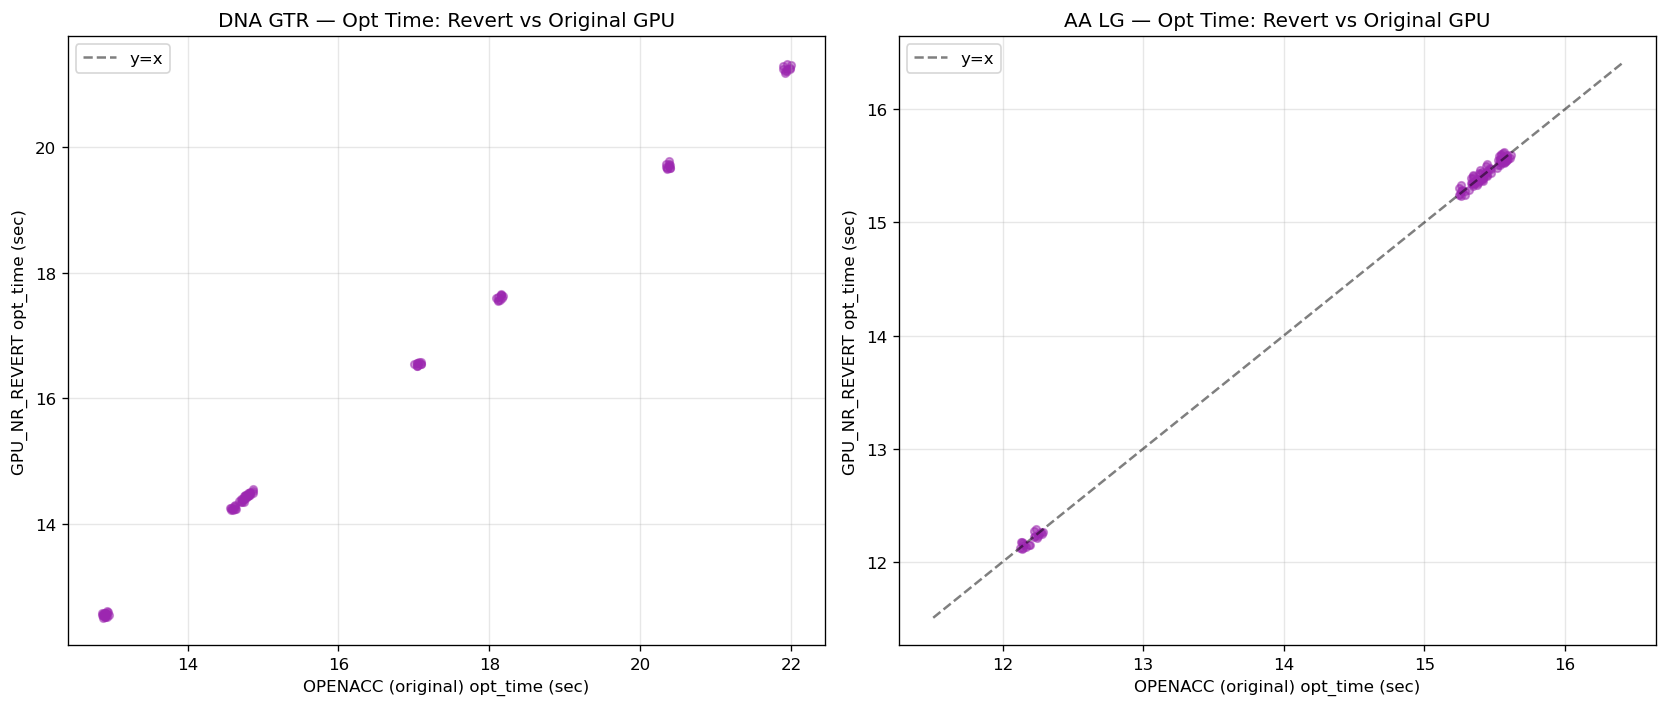

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, dt in enumerate(['DNA', 'AA']):
    model = 'GTR' if dt == 'DNA' else 'LG'
    subset = df_cmp[df_cmp['data_type'] == dt]
    
    gpu_orig = subset[subset['backend'] == 'OPENACC'].groupby(['tree', 'run'])['opt_time'].first()
    gpu_revert = subset[subset['backend'] == 'GPU_NR_REVERT'].groupby(['tree', 'run'])['opt_time'].first()
    common = gpu_orig.index.intersection(gpu_revert.index)
    
    if len(common) == 0: continue
    
    ax = axes[idx]
    x = gpu_orig.loc[common].values
    y = gpu_revert.loc[common].values
    ax.scatter(x, y, alpha=0.5, s=20, c=backend_colors['GPU_NR_REVERT'])
    
    lims = [min(x.min(), y.min()) * 0.95, max(x.max(), y.max()) * 1.05]
    ax.plot(lims, lims, 'k--', alpha=0.5, label='y=x')
    ax.set_xlabel('OPENACC (original) opt_time (sec)')
    ax.set_ylabel('GPU_NR_REVERT opt_time (sec)')
    ax.set_title(f'{dt} {model} — Opt Time: Revert vs Original GPU')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f'scatter_revert_vs_original.png'), bbox_inches='tight')
plt.show()

# 10. Log-Likelihood Heatmap: All Backends

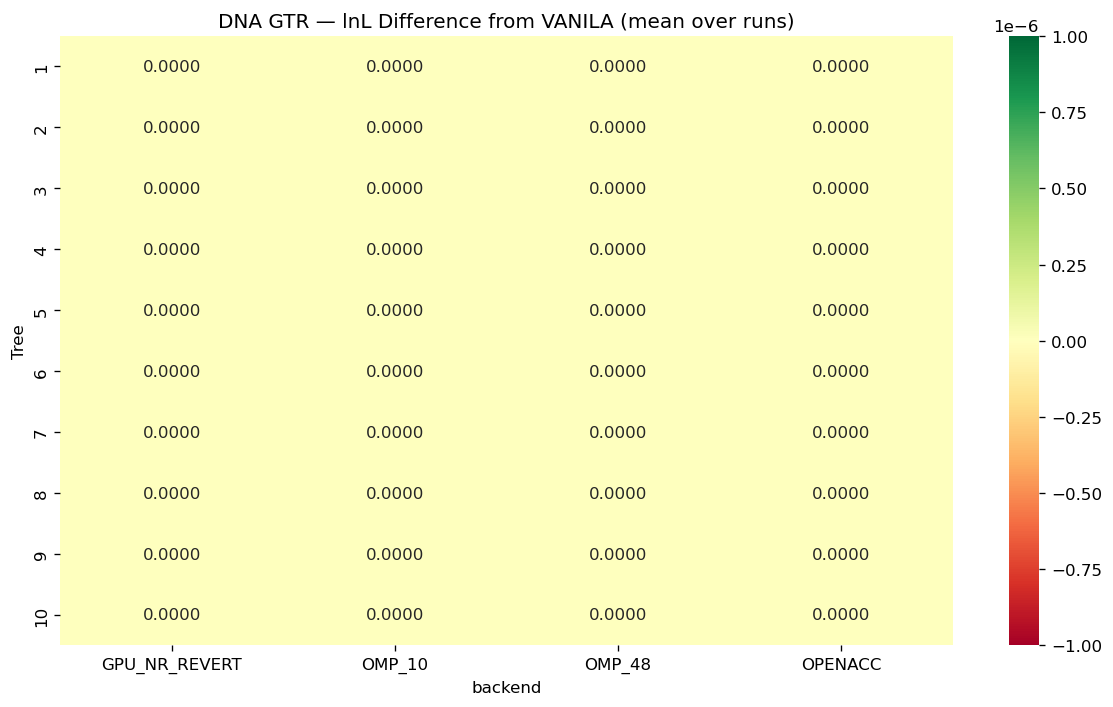

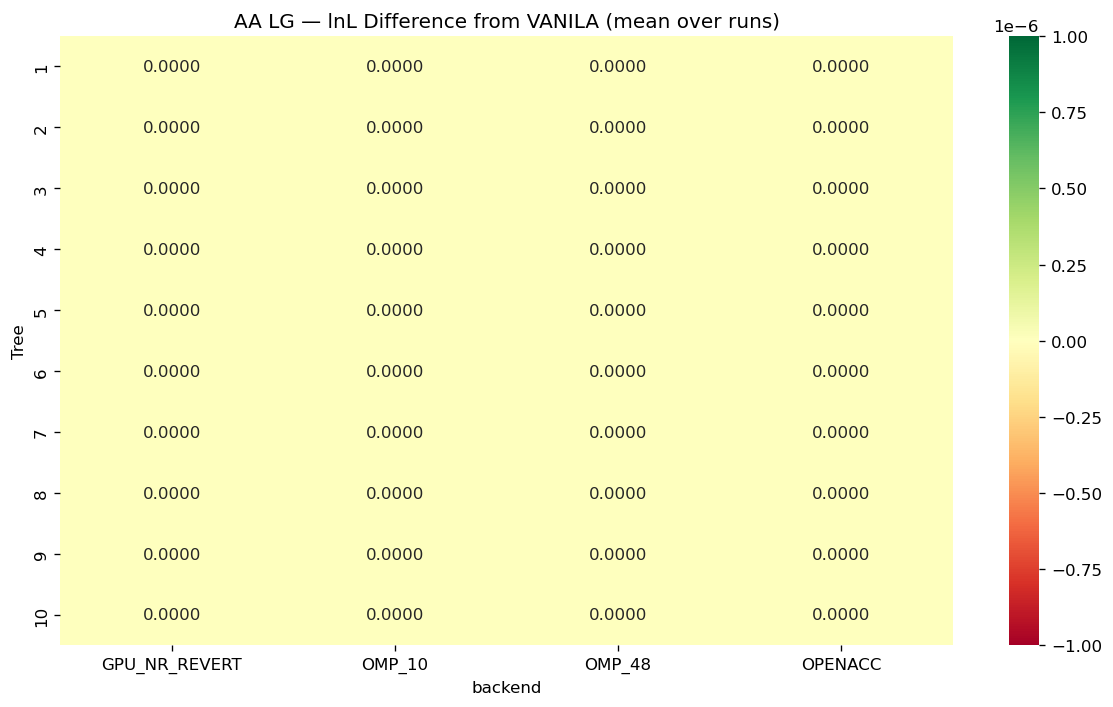

In [12]:
for dt in ['DNA', 'AA']:
    model = 'GTR' if dt == 'DNA' else 'LG'
    subset = df_cmp[df_cmp['data_type'] == dt]
    
    # Mean lnL per tree per backend
    pivot = subset.groupby(['tree', 'backend'])['optimal_ll'].mean().unstack()
    
    # Compute differences from VANILA
    if 'VANILA' in pivot.columns:
        diff_pivot = pivot.subtract(pivot['VANILA'], axis=0).drop(columns='VANILA', errors='ignore')
        
        fig, ax = plt.subplots(figsize=(10, 6))
        vmax = max(diff_pivot.abs().max().max(), 1e-6)
        sns.heatmap(diff_pivot, annot=True, fmt='.4f', cmap='RdYlGn', center=0,
                    ax=ax, vmin=-vmax, vmax=vmax)
        ax.set_title(f'{dt} {model} — lnL Difference from VANILA (mean over runs)')
        ax.set_ylabel('Tree')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f'll_diff_heatmap_{dt}.png'), bbox_inches='tight')
        plt.show()

# 11. Summary Table

In [13]:
# Final summary table
summary_rows = []
for dt in ['DNA', 'AA']:
    model = 'GTR' if dt == 'DNA' else 'LG'
    subset = df_cmp[df_cmp['data_type'] == dt]
    
    for backend in backend_order:
        bk = subset[subset['backend'] == backend]
        if len(bk) == 0: continue
        
        vanila = subset[subset['backend'] == 'VANILA']
        ll_diff_from_vanila = np.nan
        speedup_opt = np.nan
        speedup_wc = np.nan
        
        if len(vanila) > 0:
            ll_diff_from_vanila = abs(bk['optimal_ll'].mean() - vanila['optimal_ll'].mean())
            speedup_opt = vanila['opt_time'].mean() / bk['opt_time'].mean()
            speedup_wc = vanila['wallclock'].mean() / bk['wallclock'].mean()
        
        summary_rows.append({
            'Data': dt,
            'Model': model,
            'Backend': backend,
            'Runs': len(bk),
            'Opt Time (mean)': f"{bk['opt_time'].mean():.2f}s",
            'Wallclock (mean)': f"{bk['wallclock'].mean():.2f}s",
            'Opt Rounds (mean)': f"{bk['opt_rounds'].mean():.1f}",
            'Optimal lnL (mean)': f"{bk['optimal_ll'].mean():.4f}",
            '|lnL - VANILA|': f"{ll_diff_from_vanila:.6f}" if not np.isnan(ll_diff_from_vanila) else 'N/A',
            'Speedup (opt)': f"{speedup_opt:.2f}x" if not np.isnan(speedup_opt) else 'N/A',
            'Speedup (wc)': f"{speedup_wc:.2f}x" if not np.isnan(speedup_wc) else 'N/A',
        })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

Data Model       Backend  Runs Opt Time (mean) Wallclock (mean) Opt Rounds (mean) Optimal lnL (mean) |lnL - VANILA| Speedup (opt) Speedup (wc)
 DNA   GTR        VANILA   100         142.41s          144.97s               5.2     -67437010.8901       0.000000         1.00x        1.00x
 DNA   GTR        OMP_10   100          35.67s           36.82s               5.2     -67437010.8901       0.000000         3.99x        3.94x
 DNA   GTR        OMP_48   100          14.34s           15.43s               5.2     -67437010.8901       0.000000         9.93x        9.39x
 DNA   GTR       OPENACC   100          16.29s           19.06s               5.2     -67373036.4047   63974.485413         8.74x        7.61x
 DNA   GTR GPU_NR_REVERT   100          15.78s           18.54s               5.2     -67437010.8901       0.000000         9.02x        7.82x
  AA    LG        VANILA   100         261.65s          264.38s               1.0     -86328013.7996       0.000000         1.00x        1.00x

# 12. GPU_NR_REVERT vs OPENACC: Per-Run Paired Comparison

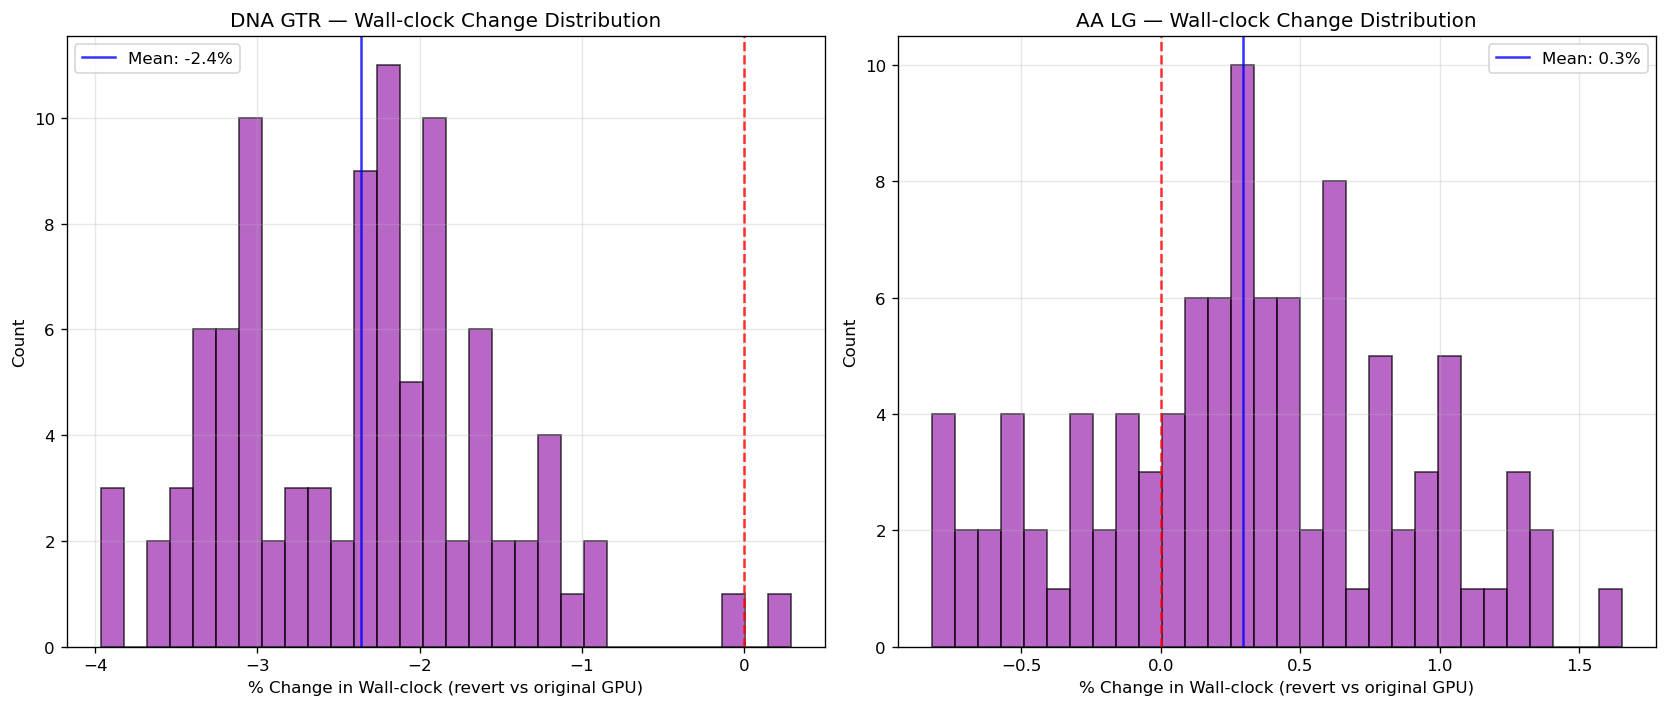

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, dt in enumerate(['DNA', 'AA']):
    model = 'GTR' if dt == 'DNA' else 'LG'
    subset = df_cmp[df_cmp['data_type'] == dt]
    
    gpu_orig = subset[subset['backend'] == 'OPENACC'].groupby(['tree', 'run'])['wallclock'].first()
    gpu_revert = subset[subset['backend'] == 'GPU_NR_REVERT'].groupby(['tree', 'run'])['wallclock'].first()
    common = gpu_orig.index.intersection(gpu_revert.index)
    
    if len(common) == 0: continue
    
    # Percentage change: (revert - orig) / orig * 100
    pct_change = ((gpu_revert.loc[common] - gpu_orig.loc[common]) / gpu_orig.loc[common] * 100)
    
    ax = axes[idx]
    ax.hist(pct_change, bins=30, color=backend_colors['GPU_NR_REVERT'], alpha=0.7, edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.8)
    ax.axvline(x=pct_change.mean(), color='blue', linestyle='-', alpha=0.8, label=f'Mean: {pct_change.mean():.1f}%')
    ax.set_xlabel('% Change in Wall-clock (revert vs original GPU)')
    ax.set_ylabel('Count')
    ax.set_title(f'{dt} {model} — Wall-clock Change Distribution')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f'wallclock_change_histogram.png'), bbox_inches='tight')
plt.show()